<a href="https://colab.research.google.com/github/vegaws1/AV-TFGD/blob/main/Copie_de_Tirer_pleinement_parti_de_votre_abonnement_%C3%A0_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tirer pleinement parti de votre abonnement à Colab



In [3]:
# =============================================================
# V2.1 SCRIPT — Baselines + Simplified Proposed Method (FIXED)
# Dataset: metasploitable network-flow CSVs (70/30 split)
# Goal: mathematically correct, concise, debuggable pipeline
# =============================================================

"""
WHAT WAS FIXED
--------------
The previous error came from selecting numeric feature columns with:
    c.startswith("f")
which accidentally matched the metadata column "flow_id".

Here we fix it by selecting ONLY columns of the form:
    f0, f1, f2, ...
using a strict regular expression.

MATHEMATICAL MODEL (Simplified Fixed Tempered Observer)
------------------------------------------------------
Given T progressive feature blocks x_t, define

    z_t = ReLU(W_t x_t + b_t)
    h_t = beta * h_{t-1} + alpha * z_t,     beta = exp(-lambda),
    p_t = softmax(U h_t + c)

where alpha in (0,1] and lambda > 0 are fixed scalars.

Training loss (concise and correct):

    L = CE(p_T, y)

No class reweighting, no sampler, no auxiliary regularization.
This version is intended as a clean sanity-check and baseline for later ablations.
"""

# =============================================================
# 1. IMPORTS
# =============================================================
import re
import json
import math
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

sns.set_context("talk")

# =============================================================
# 2. SETUP
# =============================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

META_COLS = ["flow_id", "src_ip", "src_port", "dst_ip", "dst_port", "protocol", "timestamp"]
FEATURE_RE = re.compile(r"^f\d+$")


def make_columns(n_cols: int):
    n_num = n_cols - len(META_COLS) - 1
    return META_COLS + [f"f{i}" for i in range(n_num)] + ["label"]


def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, low_memory=False)
    df.columns = make_columns(df.shape[1])
    return df


def get_numeric_feature_cols(df: pd.DataFrame):
    # Strictly keep only f0, f1, ..., never flow_id
    num_cols = [c for c in df.columns if FEATURE_RE.match(c)]
    if not num_cols:
        raise ValueError("No numeric feature columns matched the pattern ^f\\d+$")
    return num_cols


def coerce_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")
    # Safe median fill if any rare parse issue exists
    med = out[cols].median(axis=0)
    out[cols] = out[cols].fillna(med)
    return out


def build_blocks(train_df: pd.DataFrame, test_df: pd.DataFrame):
    num_cols = get_numeric_feature_cols(train_df)
    train_df = coerce_numeric(train_df, num_cols)
    test_df = coerce_numeric(test_df, num_cols)

    k1 = len(num_cols) // 3
    k2 = 2 * len(num_cols) // 3
    block_names = [
        num_cols[:k1],
        num_cols[k1:k2],
        num_cols[k2:],
    ]

    Xtr_blocks, Xte_blocks, scalers = [], [], []
    for cols in block_names:
        sc = StandardScaler()
        Xtr = sc.fit_transform(train_df[cols].values.astype(np.float32))
        Xte = sc.transform(test_df[cols].values.astype(np.float32))
        Xtr_blocks.append(Xtr.astype(np.float32))
        Xte_blocks.append(Xte.astype(np.float32))
        scalers.append(sc)

    labels = sorted(train_df["label"].astype(str).unique().tolist())
    label_to_id = {c: i for i, c in enumerate(labels)}
    ytr = train_df["label"].astype(str).map(label_to_id).values.astype(np.int64)
    yte = test_df["label"].astype(str).map(label_to_id).values.astype(np.int64)

    return Xtr_blocks, Xte_blocks, ytr, yte, labels, block_names

# =============================================================
# 3. OUTPUT HELPERS
# =============================================================
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def plot_confusion(cm, labels, path, normalize=False):
    if normalize:
        cm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1e-8, None)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalized confusion matrix" if normalize else "Confusion matrix")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def plot_prefix_metrics(df_prefix, path):
    plt.figure(figsize=(10, 6))
    plt.plot(df_prefix["prefix"], df_prefix["accuracy"], marker="o", label="Accuracy")
    plt.plot(df_prefix["prefix"], df_prefix["balanced_accuracy"], marker="s", label="Balanced Accuracy")
    plt.plot(df_prefix["prefix"], df_prefix["macro_f1"], marker="^", label="Macro-F1")
    plt.ylim(0, 1.02)
    plt.xlabel("Prefix")
    plt.ylabel("Score")
    plt.title("Early-detection performance across prefixes")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

# =============================================================
# 4. BASELINES
# =============================================================
def run_baselines(Xtr_blocks, Xte_blocks, ytr, yte, labels, out_dir: Path):
    Xtr_full = np.hstack(Xtr_blocks)
    Xte_full = np.hstack(Xte_blocks)

    models = {
        "LogReg": LogisticRegression(max_iter=400, n_jobs=-1, multi_class="auto"),
        "RF": RandomForestClassifier(n_estimators=250, n_jobs=-1, random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=80, random_state=42),
    }

    rows = []
    for name, model in models.items():
        model.fit(Xtr_full, ytr)
        yp = model.predict(Xte_full)
        row = {
            "model": name,
            "accuracy": accuracy_score(yte, yp),
            "balanced_accuracy": balanced_accuracy_score(yte, yp),
            "macro_f1": f1_score(yte, yp, average="macro", zero_division=0),
        }
        # probability-based metric if available
        if hasattr(model, "predict_proba"):
            pr = model.predict_proba(Xte_full)
            try:
                row["macro_ovr_roc_auc"] = roc_auc_score(
                    label_binarize(yte, classes=np.arange(len(labels))),
                    pr,
                    average="macro",
                    multi_class="ovr",
                )
            except Exception:
                row["macro_ovr_roc_auc"] = np.nan
        else:
            row["macro_ovr_roc_auc"] = np.nan
        rows.append(row)

    df = pd.DataFrame(rows).sort_values(by="macro_f1", ascending=False)
    df.to_csv(out_dir / "baseline_results.csv", index=False)
    return df

# =============================================================
# 5. SIMPLIFIED PROPOSED METHOD
# =============================================================
class BlockDataset(Dataset):
    def __init__(self, X_blocks, y):
        self.X = [torch.tensor(b, dtype=torch.float32) for b in X_blocks]
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        blocks = tuple(b[idx] for b in self.X)
        return blocks, self.y[idx]


class FixedTemperedObserver(nn.Module):
    def __init__(self, dims, hidden_dim=64, alpha=0.7, lam=0.3, n_classes=6):
        super().__init__()
        self.alpha = float(alpha)
        self.lam = float(lam)
        self.beta = math.exp(-self.lam)  # scalar constant, mathematically correct

        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d, hidden_dim),
                nn.ReLU(),
            ) for d in dims
        ])
        self.classifier = nn.Linear(hidden_dim, n_classes)

    def forward(self, blocks):
        batch_size = blocks[0].shape[0]
        device = blocks[0].device
        hidden_dim = self.classifier.in_features
        h = torch.zeros(batch_size, hidden_dim, device=device)
        logits_all = []

        for x_t, encoder in zip(blocks, self.encoders):
            z_t = encoder(x_t)
            h = self.beta * h + self.alpha * z_t
            logits_all.append(self.classifier(h))
        return logits_all

# =============================================================
# 6. TRAIN / EVAL
# =============================================================
def train_model(model, loader, optimizer, device, epochs=15):
    model.train()
    history = []
    for epoch in range(1, epochs + 1):
        loss_sum = 0.0
        n = 0
        for blocks, y in loader:
            blocks = [b.to(device) for b in blocks]
            y = y.to(device)
            optimizer.zero_grad()
            logits_all = model(blocks)
            loss = F.cross_entropy(logits_all[-1], y)
            loss.backward()
            optimizer.step()
            loss_sum += float(loss.item()) * y.size(0)
            n += y.size(0)
        history.append({"epoch": epoch, "train_loss": loss_sum / max(n, 1)})
    return pd.DataFrame(history)


@torch.no_grad()
def eval_model(model, loader, y_true, labels):
    model.eval()
    final_preds = []
    final_probs = []
    prefix_preds = []

    for blocks, _ in loader:
        blocks = [b.to(next(model.parameters()).device) for b in blocks]
        logits_all = model(blocks)
        probs_all = [torch.softmax(z, dim=1) for z in logits_all]
        preds_all = [p.argmax(dim=1) for p in probs_all]

        final_preds.append(preds_all[-1].cpu().numpy())
        final_probs.append(probs_all[-1].cpu().numpy())
        prefix_preds.append(np.column_stack([p.cpu().numpy() for p in preds_all]))

    yp = np.concatenate(final_preds)
    pr = np.vstack(final_probs)
    prefix_mat = np.vstack(prefix_preds)

    final_metrics = {
        "accuracy": accuracy_score(y_true, yp),
        "balanced_accuracy": balanced_accuracy_score(y_true, yp),
        "macro_f1": f1_score(y_true, yp, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, yp, average="weighted", zero_division=0),
    }
    try:
        final_metrics["macro_ovr_roc_auc"] = roc_auc_score(
            label_binarize(y_true, classes=np.arange(len(labels))),
            pr,
            average="macro",
            multi_class="ovr",
        )
    except Exception:
        final_metrics["macro_ovr_roc_auc"] = np.nan

    prefix_rows = []
    for t in range(prefix_mat.shape[1]):
        pred_t = prefix_mat[:, t]
        prefix_rows.append({
            "prefix": t + 1,
            "accuracy": accuracy_score(y_true, pred_t),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred_t),
            "macro_f1": f1_score(y_true, pred_t, average="macro", zero_division=0),
        })

    return final_metrics, pd.DataFrame(prefix_rows), yp, pr, prefix_mat

# =============================================================
# 7. MAIN
# =============================================================
def main(train_csv, test_csv, out_dir, seed=42, epochs=15, batch_size=512, hidden_dim=64, alpha=0.7, lam=0.3):
    set_seed(seed)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    tr = load_csv(train_csv)
    te = load_csv(test_csv)
    Xtr_blocks, Xte_blocks, ytr, yte, labels, block_names = build_blocks(tr, te)

    summary = {
        "train_shape": list(tr.shape),
        "test_shape": list(te.shape),
        "labels": labels,
        "train_label_counts": tr["label"].astype(str).value_counts().to_dict(),
        "test_label_counts": te["label"].astype(str).value_counts().to_dict(),
        "n_blocks": len(Xtr_blocks),
        "block_dims": [int(b.shape[1]) for b in Xtr_blocks],
        "alpha": alpha,
        "lambda": lam,
    }
    save_json(summary, out_dir / "dataset_summary.json")

    # ---------- Baselines ----------
    baseline_df = run_baselines(Xtr_blocks, Xte_blocks, ytr, yte, labels, out_dir)
    print("\nBaseline results:\n", baseline_df)

    # ---------- Simplified proposed model ----------
    ds_tr = BlockDataset(Xtr_blocks, ytr)
    ds_te = BlockDataset(Xte_blocks, yte)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False)

    model = FixedTemperedObserver(
        dims=[b.shape[1] for b in Xtr_blocks],
        hidden_dim=hidden_dim,
        alpha=alpha,
        lam=lam,
        n_classes=len(labels),
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    hist = train_model(model, dl_tr, optimizer, device=device, epochs=epochs)
    hist.to_csv(out_dir / "training_history.csv", index=False)

    metrics, prefix_df, y_pred, y_prob, prefix_preds = eval_model(model, dl_te, yte, labels)
    pd.DataFrame([metrics]).to_csv(out_dir / "simplified_proposed_metrics.csv", index=False)
    prefix_df.to_csv(out_dir / "prefix_metrics.csv", index=False)

    report = classification_report(yte, y_pred, target_names=labels, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(out_dir / "classification_report.csv")

    cm = confusion_matrix(yte, y_pred)
    np.savetxt(out_dir / "confusion_matrix.csv", cm, fmt="%d", delimiter=",")
    plot_confusion(cm, labels, out_dir / "confusion_matrix.png", normalize=False)
    plot_confusion(cm, labels, out_dir / "confusion_matrix_normalized.png", normalize=True)
    plot_prefix_metrics(prefix_df, out_dir / "prefix_metrics.png")

    pred_df = pd.DataFrame({
        "true_label": [labels[i] for i in yte],
        "pred_label": [labels[i] for i in y_pred],
        "max_prob": y_prob.max(axis=1),
    })
    for t in range(prefix_preds.shape[1]):
        pred_df[f"prefix_{t+1}_pred"] = [labels[j] for j in prefix_preds[:, t]]
    for j, name in enumerate(labels):
        pred_df[f"prob_{name}"] = y_prob[:, j]
    pred_df.to_csv(out_dir / "test_predictions.csv", index=False)

    print("\nSimplified proposed method metrics:")
    print(json.dumps(metrics, indent=2))
    print("\nSaved outputs in:", out_dir)


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_csv", default="M_Dataset_metasploitable-2_70.csv")
    parser.add_argument("--test_csv", default="M_Dataset_metasploitable-2_30.csv")
    parser.add_argument("--out_dir", default="results_v2_fixed")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--epochs", type=int, default=15)
    parser.add_argument("--batch_size", type=int, default=512)
    parser.add_argument("--hidden_dim", type=int, default=64)
    parser.add_argument("--alpha", type=float, default=0.7)
    parser.add_argument("--lam", type=float, default=0.3)

    # Notebook-safe
    args, unknown = parser.parse_known_args()
    if unknown:
        print("Ignoring unknown args:", unknown)

    main(
        train_csv=args.train_csv,
        test_csv=args.test_csv,
        out_dir=args.out_dir,
        seed=args.seed,
        epochs=args.epochs,
        batch_size=args.batch_size,
        hidden_dim=args.hidden_dim,
        alpha=args.alpha,
        lam=args.lam,
    )


Ignoring unknown args: ['-f', '/root/.local/share/jupyter/runtime/kernel-415f94e4-2d42-4241-8a6e-eece523cdb0c.json']
Using device: cpu



KeyboardInterrupt



# Google Colab est disponible dans VS Code !
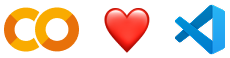

Essayez la nouvelle <a href="https://marketplace.visualstudio.com/items?itemName=Google.colab">extension Google Colab</a> pour Visual Studio Code. Vous pouvez vous lancer en quelques clics :

*  Dans VS Code, ouvrez la vue <strong><em>Extensions</em></strong> et recherchez "Google Colab" pour l'installer.
*  Ouvrez le sélecteur de kernel en créant ou en ouvrant un fichier de notebook <code>.ipynb</code> dans votre espace de travail local, puis en exécutant une cellule ou en cliquant sur le bouton <strong><em>Select Kernel</em></strong> &#40;Sélectionner le kernel&#41; en haut à droite.
*  Cliquez sur <strong><em>Colab</em></strong>, puis sélectionnez l'environnement d'exécution souhaité et connectez-vous avec votre compte Google. C'est tout !

Pour en savoir plus, consultez l'<a href="https://developers.googleblog.com/google-colab-is-coming-to-vs-code">annonce sur notre blog</a>.

# Access Popular LLMs via Google-Colab-AI Without an API Key

Users with Colab's paid plans have free access to most popular LLMs via google-colab-ai Python library. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")
print(response)

## GPU plus rapides

<p>Les utilisateurs ayant souscrit l'un des forfaits payants de Colab ont accès à des GPU plus rapides et à plus de mémoire. Vous pouvez mettre à niveau les paramètres GPU de votre notebook via <code>Environnement d'exécution &gt; Modifier le type d'exécution</code> dans le menu pour sélectionner plusieurs options d'accélérateur, sous réserve de disponibilité.</p>
<p>La version sans frais de Colab permet d'accéder aux GPU T4 de Nvidia, selon les restrictions de quota et la disponibilité.</p>

Vous pouvez voir le GPU qui vous est attribué à tout moment en exécutant la cellule suivante. Si le résultat d'exécution de la cellule de code ci-dessous est "Not connected to a GPU" &#40;"Non connecté à un GPU"&#41;, vous pouvez modifier l'environnement d'exécution en sélectionnant <code>Environnement d'exécution &gt; Modifier le type d'exécution</code> dans le menu pour activer un accélérateur GPU. Ensuite, réexécutez la cellule de code.

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Pour utiliser un GPU avec votre notebook, sélectionnez <code>Environnement d'exécution &gt; Modifier le type d'exécution</code>, puis définissez l'option d'accélérateur matériel de votre choix.

## Plus de mémoire

Les utilisateurs ayant souscrit l'un des forfaits payants de Colab ont accès aux VM à haute capacité de mémoire dès qu'elles sont disponibles. Des GPU plus puissants sont toujours proposés avec les VM à haute capacité de mémoire.
Vous pouvez surveiller la quantité de mémoire à votre disposition à tout moment en exécutant la cellule de code suivante. Si le résultat d'exécution de la cellule de code ci-dessous est "Not using a high-RAM runtime" &#40;"Un environnement d'exécution à mémoire RAM élevée n'est pas utilisé"&#41;, vous pouvez activer un environnement d'exécution à mémoire RAM élevée en sélectionnant <code>Environnement d'exécution &gt; Modifier le type d'exécution</code> dans le menu. Ensuite, sélectionnez "Mémoire RAM élevée" dans le bouton d'activation de la configuration de l'environnement d'exécution, puis réexécutez la cellule de code.

In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

## Environnements d'exécution plus durables

Tous les environnements d'exécution Colab sont réinitialisés après un certain temps &#40;plus rapidement s'il ne s'agit pas d'un environnement d'exécution de code&#41;. Les utilisateurs de Colab Pro et Colab Pro+ ont accès à des environnements d'exécution plus durables que les utilisateurs de la version sans frais de Colab.

## Exécution en arrière-plan

Les utilisateurs de Colab Pro+ ont accès à l'exécution en arrière-plan, qui permet aux notebooks de poursuivre leur exécution même après la fermeture d'un onglet de navigateur. Cette option est toujours activée dans les environnements d'exécution Pro+ tant que des unités de calcul sont disponibles.


## Assouplir les limites de ressources dans Colab Pro

Vos ressources ne sont pas illimitées dans Colab. Pour profiter pleinement de Colab, évitez d'utiliser des ressources lorsque vous n'en avez pas besoin. Par exemple, n'utilisez un GPU que si nécessaire et fermez les onglets Colab lorsque vous avez terminé.

Si vous êtes confronté à des limites, vous pouvez les assouplir en achetant davantage d'unités de calcul via le <a href="https://colab.research.google.com/signup">paiement à l'usage</a>. Tout le monde peut le faire, aucun abonnement n'est requis.

## Envoyer vos commentaires

<p>Si vous avez des commentaires, n'hésitez pas à nous les faire parvenir. Pour cela, il vous suffit de sélectionner Aide &gt; Envoyer des commentaires. Si vous faites l'objet de limites d'utilisation dans Colab Pro, envisagez de vous abonner à Colab Pro+.</p>
<p>Si vous rencontrez des erreurs ou d'autres problèmes de facturation &#40;paiements&#41; avec Colab Pro, Colab Pro+ ou le paiement à l'usage, veuillez contacter <a href="mailto:colab-billing@google.com">colab-billing@google.com</a>.</p>

## Autres ressources

### Utiliser les notebooks dans Colab
- [Présentation de Colab](/notebooks/basic_features_overview.ipynb)
- [Guide de Markdown](/notebooks/markdown_guide.ipynb)
- [Importer des bibliothèques et installer des dépendances](/notebooks/snippets/importing_libraries.ipynb)
- [Enregistrer et charger des notebooks dans GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulaires interactifs](/notebooks/forms.ipynb)
- [Widgets interactifs](/notebooks/widgets.ipynb)

<a name="working-with-data"></a>
### Utiliser les données
- [Chargement de données : Drive, Sheets et Google Cloud Storage](/notebooks/io.ipynb)
- [Graphiques : visualiser les données](/notebooks/charts.ipynb)
- [Premiers pas avec BigQuery](/notebooks/bigquery.ipynb)

### Cours d'initiation au Machine Learning
Vous trouverez ci-dessous quelques-uns des notebooks de la formation Google en ligne sur le machine learning. Consultez la <a href="https://developers.google.com/machine-learning/crash-course/">formation complète en ligne</a> pour en savoir plus.
- [Présentation du DataFrame pandas](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Présentation de RAPIDS cuDF pour accélérer pandas](https://nvda.ws/rapids-cudf)
- [Premiers pas avec le mode accélérateur de cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)


<a name="using-accelerated-hardware"></a>
### Utiliser le matériel accéléré
- [Entraîner un CNN à classer les chiffres manuscrits de l'ensemble de données MNIST à l'aide de l'API Flax NNX](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Entraîner un Vision Transformer &#40;ViT&#41; pour la classification d'images avec JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Classification de texte avec un modèle de langage Transformer utilisant JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<a name="machine-learning-examples"></a>

## Exemples de machine learning

Voici quelques exemples :

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Entraîner un modèle de langage miniGPT avec JAX AI Stack</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Affinage LoRA/QLoRA pour LLM avec Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Affinage d'un sous-ensemble de paramètres de Gemma avec LoRA et QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Chargement des points de contrôle Hugging Face Transformers</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Quantification d'entiers de 8 bits dans Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Entraînement et inférence Float8 avec un modèle Transformer simple</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Pré-entraînement d'un Transformer à partir de zéro avec KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Convnet MNIST simple</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Classification d'images à partir de zéro à l'aide de Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Classification d'images avec KerasHub</a>
